# Trust and Equitable Access in Digital Markets
### A Computational Simulation of Reputation, Platform Rules, and Income Uncertainty

## Research Question

How do platform rules, reputation information, and income uncertainty jointly affect trust, speculation, and genuine consumer access to scarce goods?

### Three disciplinary perspectives

- **Behavioral Science:** Reputation information affects perceived trust and willingness to participate.
- **Economics:** Income uncertainty affects participation, surplus, and allocation.
- **Computer Science:** Agent-based simulation allows systematic comparison of platform mechanisms under heterogeneous conditions.

This notebook implements a simplified computational model for the PS1 proposal.
The simulation generates theoretical patterns rather than empirical estimates from real marketplace data.

## 1. Model Design

### Actors
- Genuine consumers: buyers who want the good for personal use.
- Speculators: buyers who value opportunities to resell or profit from the good.

### Actions
Each buyer submits a willingness-to-pay bid for a scarce good.

### Information
Buyers may receive:
- No History
- Recent History
- Full History

They also face different levels of income uncertainty.

### Platform Rules
1. Refundable + Non-transferable
2. Transferable + Non-refundable

### Incentives
- Genuine consumers benefit from obtaining the good.
- Speculators benefit from resale opportunities.
- Buyers with greater income uncertainty are more sensitive to financial risk.

### Scale
The simulation represents many buyers competing for a limited number of goods over repeated rounds.

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product

# Reproducibility
SEED = 42
rng = np.random.default_rng(SEED)

# Market parameters
N_BUYERS = 100
N_GOODS = 30
N_ROUNDS = 200

# Buyer composition
SPECULATOR_SHARE = 0.30

# Conditions
PLATFORM_RULES = [
    "Refundable + Non-transferable",
    "Transferable + Non-refundable"
]

REPUTATION_LEVELS = [
    "No History",
    "Recent History",
    "Full History"
]

INCOME_UNCERTAINTY = [
    "Low",
    "High"
]

# Economic values
PRODUCT_VALUE = 100
BASE_RESALE_VALUE = 120

print("Simulation parameters loaded.")
print(f"Buyers per round: {N_BUYERS}")
print(f"Goods per round: {N_GOODS}")
print(f"Simulation rounds per condition: {N_ROUNDS}")
print(f"Random seed: {SEED}")

Simulation parameters loaded.
Buyers per round: 100
Goods per round: 30
Simulation rounds per condition: 200
Random seed: 42


In [19]:
def reputation_factor(reputation_level, rng):
    """
    Stylized behavioral representation of reputation information.

    No History:
        Buyer has no seller-history information.

    Recent History:
        Buyer observes recent performance, which provides
        useful but noisy information.

    Full History:
        Buyer observes a larger lifetime history and therefore
        receives a more stable signal.
    """

    if reputation_level == "No History":
        return 1.00

    elif reputation_level == "Recent History":
        return np.clip(
            rng.normal(0.96, 0.06),
            0.80,
            1.10
        )

    elif reputation_level == "Full History":
        return np.clip(
            rng.normal(1.00, 0.035),
            0.85,
            1.12
        )


def income_factor(uncertainty, rng):
    """
    Income uncertainty is modeled as a financial-risk constraint.

    Low uncertainty:
        Buyers face relatively stable purchasing capacity.

    High uncertainty:
        Buyers become more financially cautious.
    """

    if uncertainty == "Low":
        return np.clip(
            rng.normal(1.00, 0.04),
            0.90,
            1.08
        )

    elif uncertainty == "High":
        return np.clip(
            rng.normal(0.88, 0.08),
            0.65,
            1.02
        )


def calculate_bid(
    buyer_type,
    reputation_level,
    uncertainty,
    platform_rule,
    rng
):
    """
    Calculate buyer willingness to pay.

    The bid is a maximum willingness-to-pay amount,
    not necessarily the final transaction price.
    """

    trust = reputation_factor(
        reputation_level,
        rng
    )

    financial = income_factor(
        uncertainty,
        rng
    )

    if buyer_type == "Genuine":

        # Genuine consumers primarily value the product itself.
        base_value = PRODUCT_VALUE

        # Refundability reduces financial risk.
        if platform_rule == "Refundable + Non-transferable":
            rule_factor = 1.05
        else:
            rule_factor = 0.98

        bid = (
            base_value
            * trust
            * financial
            * rule_factor
        )

    else:

        # Speculators value the possibility of resale.
        resale_value = BASE_RESALE_VALUE

        # Transferability increases resale opportunities.
        if platform_rule == "Transferable + Non-refundable":
            rule_factor = 1.15
        else:
            rule_factor = 0.65

        bid = (
            resale_value
            * trust
            * financial
            * rule_factor
        )

    return np.clip(bid, 0, 150)

In [20]:
def run_round(
    platform_rule,
    reputation_level,
    uncertainty,
    rng
):
    """
    Simulate one market round.

    Buyers submit maximum willingness-to-pay bids.
    A market asking price is generated independently.
    A buyer trades only when their bid reaches the market price.

    Goods are scarce, so only buyers who satisfy the
    price condition can obtain the product, up to N_GOODS.
    """

    buyers = []

    # -----------------------------
    # 1. Generate buyer population
    # -----------------------------

    for i in range(N_BUYERS):

        buyer_type = (
            "Speculator"
            if rng.random() < SPECULATOR_SHARE
            else "Genuine"
        )

        bid = calculate_bid(
            buyer_type,
            reputation_level,
            uncertainty,
            platform_rule,
            rng
        )

        buyers.append({
            "buyer_id": i,
            "type": buyer_type,
            "bid": bid
        })

    buyers_df = pd.DataFrame(buyers)

    # -----------------------------
    # 2. Generate market asking price
    # -----------------------------

    # The asking price is hidden from the buyer
    # when the bid is formed.
    market_price = np.clip(
        rng.normal(85, 12),
        50,
        120
    )

    # -----------------------------
    # 3. Identify buyers willing to trade
    # -----------------------------

    eligible = buyers_df[
        buyers_df["bid"] >= market_price
    ].copy()

    # -----------------------------
    # 4. Scarcity constraint
    # -----------------------------

    # If demand exceeds supply, highest bidders receive
    # the limited goods.
    if len(eligible) > N_GOODS:

        winners = (
            eligible
            .sort_values("bid", ascending=False)
            .head(N_GOODS)
            .copy()
        )

    else:

        winners = eligible.copy()

    # -----------------------------
    # 5. Transaction outcomes
    # -----------------------------

    transaction_rate = (
        len(winners) / N_BUYERS
    )

    if len(winners) > 0:

        genuine_winners = winners[
            winners["type"] == "Genuine"
        ]

        speculator_winners = winners[
            winners["type"] == "Speculator"
        ]

    else:

        genuine_winners = winners
        speculator_winners = winners

    # -----------------------------
    # 6. Genuine consumer access
    # -----------------------------

    total_genuine = (
        buyers_df["type"] == "Genuine"
    ).sum()

    genuine_access_rate = (
        len(genuine_winners) / total_genuine
        if total_genuine > 0
        else 0
    )

    # -----------------------------
    # 7. Speculation
    # -----------------------------

    speculation_rate = (
        len(speculator_winners) / len(winners)
        if len(winners) > 0
        else 0
    )

    # -----------------------------
    # 8. Consumer surplus
    # -----------------------------

    # Surplus is based on the actual transaction price,
    # not the buyer's maximum bid.
    if len(genuine_winners) > 0:

        genuine_surplus = (
            PRODUCT_VALUE - market_price
        )

        genuine_surplus = max(
            genuine_surplus,
            0
        )

    else:

        genuine_surplus = 0

    # -----------------------------
    # 9. Return outcomes
    # -----------------------------

    return {
        "transaction_rate": transaction_rate,
        "genuine_access_rate": genuine_access_rate,
        "speculation_rate": speculation_rate,
        "genuine_surplus": genuine_surplus,
        "average_bid": buyers_df["bid"].mean(),
        "market_price": market_price,
        "number_of_trades": len(winners)
    }

In [21]:
def run_simulation():

    results = []

    conditions = list(
        product(
            PLATFORM_RULES,
            REPUTATION_LEVELS,
            INCOME_UNCERTAINTY
        )
    )

    for (
        platform_rule,
        reputation_level,
        uncertainty
    ) in conditions:

        for round_id in range(N_ROUNDS):

            outcome = run_round(
                platform_rule,
                reputation_level,
                uncertainty,
                rng
            )

            outcome["platform_rule"] = platform_rule
            outcome["reputation"] = reputation_level
            outcome["income_uncertainty"] = uncertainty
            outcome["round"] = round_id

            results.append(outcome)

    return pd.DataFrame(results)


results = run_simulation()

print("Simulation completed.")
print(f"Number of simulated observations: {len(results)}")

results.head()

Simulation completed.
Number of simulated observations: 2400


,transaction_rate,genuine_access_rate,speculation_rate,genuine_surplus,average_bid,market_price,number_of_trades,platform_rule,reputation,income_uncertainty,round
0,0.3,0.441176,0.0,16.961315,96.185162,83.038685,30,Refundable + Non-transferable,No History,Low,0
1,0.3,0.454545,0.0,5.878403,96.499591,94.121597,30,Refundable + Non-transferable,No History,Low,1
2,0.3,0.416667,0.0,12.011567,97.064379,87.988433,30,Refundable + Non-transferable,No History,Low,2
3,0.3,0.422535,0.0,30.003786,96.667965,69.996214,30,Refundable + Non-transferable,No History,Low,3
4,0.3,0.428571,0.0,20.793482,96.690700,79.206518,30,Refundable + Non-transferable,No History,Low,4


In [22]:
summary = (
    results
    .groupby([
        "platform_rule",
        "reputation",
        "income_uncertainty"
    ])
    .agg(
        Genuine_Access_Rate=("genuine_access_rate", "mean"),
        Speculation_Rate=("speculation_rate", "mean"),
        Transaction_Rate=("transaction_rate", "mean"),
        Average_Genuine_Surplus=("genuine_surplus", "mean"),
        Average_Bid=("average_bid", "mean")
    )
    .reset_index()
)

summary

,platform_rule,reputation,income_uncertainty,Genuine_Access_Rate,Speculation_Rate,Transaction_Rate,Average_Genuine_Surplus,Average_Bid
0,Refundable + Non-transferable,Full History,High,0.397996,0.000000,0.27810,15.654802,85.207434
1,Refundable + Non-transferable,Full History,Low,0.419462,0.000000,0.29335,16.706673,96.933348
2,Refundable + Non-transferable,No History,High,0.361855,0.000000,0.25315,15.062478,85.144175
3,Refundable + Non-transferable,No History,Low,0.423845,0.000000,0.29625,15.767605,96.960432
4,Refundable + Non-transferable,Recent History,High,0.364777,0.000167,0.25360,15.344830,81.721652
5,Refundable + Non-transferable,Recent History,Low,0.405432,0.000000,0.28230,14.322427,92.940446
6,Transferable + Non-refundable,Full History,High,0.033746,0.916045,0.29690,10.977041,96.303661
7,Transferable + Non-refundable,Full History,Low,0.024771,0.937167,0.29915,7.956328,109.736515
8,Transferable + Non-refundable,No History,High,0.028004,0.929810,0.29550,8.462088,96.434897
9,Transferable + Non-refundable,No History,Low,0.019297,0.951667,0.29945,7.183353,110.076173


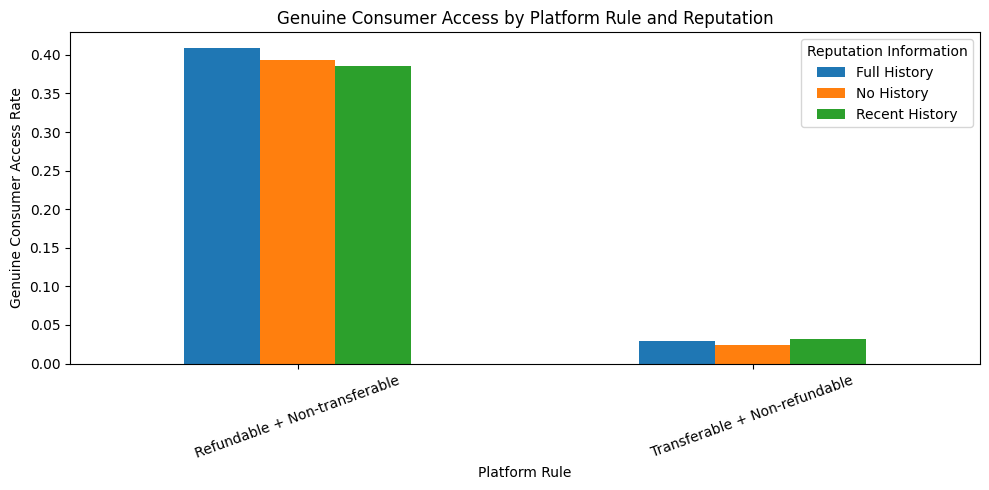

In [23]:
access_plot = (
    summary
    .groupby([
        "platform_rule",
        "reputation"
    ])["Genuine_Access_Rate"]
    .mean()
    .unstack()
)

access_plot.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title(
    "Genuine Consumer Access by Platform Rule and Reputation"
)

plt.ylabel(
    "Genuine Consumer Access Rate"
)

plt.xlabel(
    "Platform Rule"
)

plt.xticks(rotation=20)

plt.legend(
    title="Reputation Information"
)

plt.tight_layout()
plt.show()

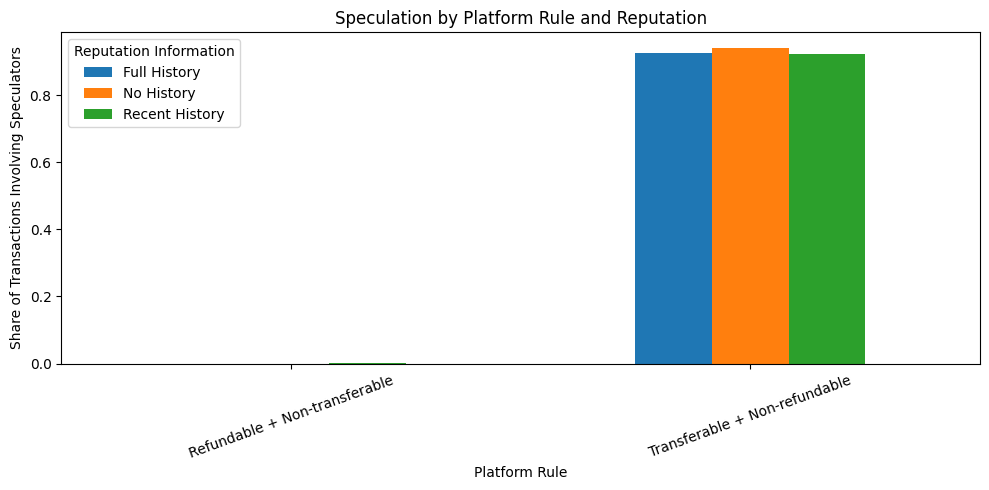

In [24]:
speculation_plot = (
    summary
    .groupby([
        "platform_rule",
        "reputation"
    ])["Speculation_Rate"]
    .mean()
    .unstack()
)

speculation_plot.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title(
    "Speculation by Platform Rule and Reputation"
)

plt.ylabel(
    "Share of Transactions Involving Speculators"
)

plt.xlabel(
    "Platform Rule"
)

plt.xticks(rotation=20)

plt.legend(
    title="Reputation Information"
)

plt.tight_layout()
plt.show()

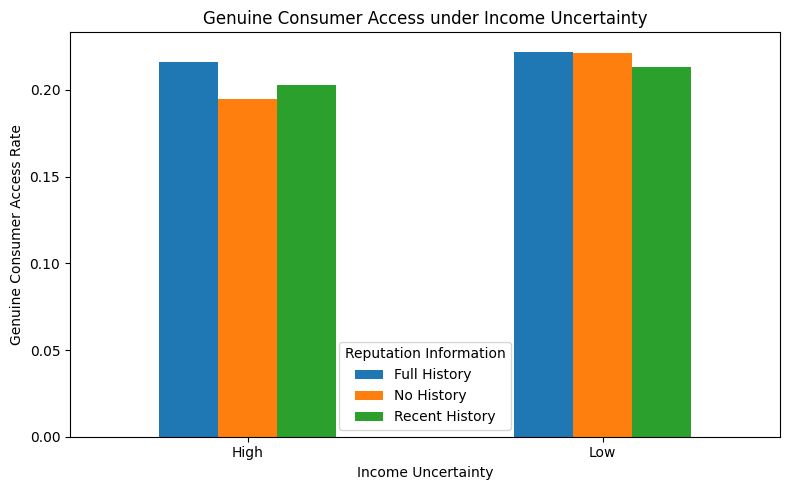

In [25]:
uncertainty_plot = (
    summary
    .groupby([
        "income_uncertainty",
        "reputation"
    ])["Genuine_Access_Rate"]
    .mean()
    .unstack()
)

uncertainty_plot.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title(
    "Genuine Consumer Access under Income Uncertainty"
)

plt.ylabel(
    "Genuine Consumer Access Rate"
)

plt.xlabel(
    "Income Uncertainty"
)

plt.xticks(rotation=0)

plt.legend(
    title="Reputation Information"
)

plt.tight_layout()
plt.show()

In [ ]:
# Robustness check: vary the proportion of speculators

speculator_shares = [0.10, 0.30, 0.50]

robustness_results = []

original_share = SPECULATOR_SHARE

for share in speculator_shares:

    SPECULATOR_SHARE = share

    temp_rng = np.random.default_rng(SEED)

    for platform_rule in PLATFORM_RULES:

        for reputation_level in REPUTATION_LEVELS:

            for uncertainty in INCOME_UNCERTAINTY:

                round_outcomes = []

                for _ in range(100):

                    outcome = run_round(
                        platform_rule,
                        reputation_level,
                        uncertainty,
                        temp_rng
                    )

                    round_outcomes.append(outcome)

                avg_access = np.mean([
                    x["genuine_access_rate"]
                    for x in round_outcomes
                ])

                avg_speculation = np.mean([
                    x["speculation_rate"]
                    for x in round_outcomes
                ])

                robustness_results.append({
                    "speculator_share": share,
                    "platform_rule": platform_rule,
                    "reputation": reputation_level,
                    "income_uncertainty": uncertainty,
                    "genuine_access": avg_access,
                    "speculation": avg_speculation
                })

SPECULATOR_SHARE = original_share

robustness_df = pd.DataFrame(robustness_results)

robustness_df.head()

In [ ]:
robustness_plot = (
    robustness_df
    .groupby("speculator_share")
    ["genuine_access"]
    .mean()
)

robustness_plot.plot(
    kind="line",
    marker="o",
    figsize=(8, 5)
)

plt.title("Robustness Check: Speculator Share and Genuine Consumer Access")
plt.xlabel("Speculator Share")
plt.ylabel("Average Genuine Consumer Access Rate")
plt.tight_layout()
plt.show()

## Simulation Assumptions

The simulation is intentionally stylized and is designed to test mechanisms rather than estimate real-world effects. Reputation information changes buyers' perceived seller reliability; income uncertainty changes financial risk tolerance; platform rules change the relative incentives of genuine consumers and speculators. Market prices are generated independently of buyer bids, while scarce supply limits allocation.

The model therefore asks whether these mechanisms can generate systematic differences in transaction rates, genuine consumer access, speculation, and surplus.

## 2. Interpretation

### Behavioral interpretation

The model represents reputation information as a signal that changes buyers' perceived reliability and willingness to bid. Comparing No History, Recent History, and Full History allows the simulation to examine whether additional reputation information changes participation and purchasing behavior.

### Economic interpretation

Income uncertainty changes the financial risk associated with purchasing. The model therefore evaluates not only whether goods are allocated, but also whether genuine consumers can participate and obtain surplus from the market.

### Computational interpretation

The agent-based simulation makes it possible to systematically compare platform rules, reputation conditions, buyer types, and financial conditions across repeated market environments.

### Interdisciplinary tension

A platform mechanism may improve transaction efficiency or make allocation easier while simultaneously increasing speculation and reducing access for genuine consumers. Therefore, the mechanism that maximizes market efficiency is not necessarily the mechanism that maximizes equitable access.

## 3. Limitations

This is a stylized computational model rather than an empirical estimate of real marketplace behavior. Buyer decisions are represented by simplified behavioral rules, reputation signals are modeled rather than observed from real platforms, and the model does not use real transaction data.

The simulation is therefore useful for identifying mechanisms and generating testable hypotheses, but its results should not be interpreted as evidence that a particular platform rule is empirically superior.

A future study should test the proposed mechanisms with human participants and, where possible, real marketplace or ticketing data.

## 4. Reproducibility

The simulation uses a fixed random seed (`SEED = 42`) so that the main results can be reproduced.

To reproduce the analysis:

1. Run all cells from top to bottom.
2. Modify the parameters in the Parameters section if desired.
3. Re-run the simulation.
4. The summary table and figures will be generated automatically.

The model uses Python, NumPy, Pandas, and Matplotlib. No external API, database, paid service, or private data is required.